<a href="https://colab.research.google.com/github/hanbiphyun/ESSA_YB/blob/main/ESAA_OB_week2_1_%ED%95%84%EC%82%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#ch.8 텍스트 분석
p.534-538, 550-565

**토픽 모델링- 20 뉴스그룹**
: 문서 집합에 숨어있는 주제를 찾아내는 것
- 중심단어를 함축적으로 추출
- 기법 : 주로 LSA (Latent Semantic Analysis) & LDA (Latent Dirichlet Allocation) -> 이번에 LDA로
- LatentDirichletAllocation 클래스 제공
- 과정 : categories 파라미터를 통해 필요한 주제 필터링하여 추출 -> 추출된 텍스트를 count 기반으로 벡터화 변환
  - LDA는 Count기반 벡터화


In [4]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# 모터사이클, 야구, 그래픽스, 윈도우즈, 중동, 기독교, 전자공학, 의학 8개 주제를 추출
cats= ['rec.motorcycles', 'rec.sport.baseball','comp.graphics','comp.windows.x',
       'talk.politics.mideast','soc.religion.christian','sci.electronics','sci.med']

# 위에서 cats 변수로 기재된 카테고리만 추출. featch_20newsgroups()의 categories에 cats 입력
news_df= fetch_20newsgroups(subset='all', remove=('headers','footers','quotes'),
                            categories=cats, random_state=0)
# LDA는 Count 기반의 벡터화만 적용합니다.
count_vect= CountVectorizer(max_df=0.95, max_features=1000, min_df=2, stop_words='english',
                            ngram_range=(1,2))
feat_vect= count_vect.fit_transform(news_df.data)
print('CountVectorizer Shape:', feat_vect.shape)

CountVectorizer Shape: (7862, 1000)


- feat_vect 모두 7862개의 문서가 1000개의 피처로 구성된 행렬 데이터
- LDA 토픽 모델링 수행
- 8개의 토픽 개수 지정
- LatentDirichletAllocation.fit 수행 시 위 객체가 components_ 속성값 가짐
  - components_는 각 토픽별로 각 word 피처가 얼마나 많이 할당됐는지 수치나타냄

In [5]:
lda= LatentDirichletAllocation(n_components=8, random_state=0)
lda.fit(feat_vect)

LatentDirichletAllocation(n_components=8, random_state=0)

In [6]:
print(lda.components_.shape)
lda.components_

(8, 1000)


array([[2.69030238e+02, 1.87798026e+02, 7.09003824e+01, ...,
        1.22710343e+01, 1.06329639e+02, 7.25995512e+01],
       [1.25091799e-01, 2.46049106e+00, 1.25051902e-01, ...,
        2.80071176e+02, 1.25089783e-01, 5.05669662e+01],
       [1.33978420e+02, 1.25042012e-01, 9.98277256e+01, ...,
        1.25092219e-01, 3.31078261e+01, 1.25028398e-01],
       ...,
       [2.98813886e+01, 1.88071366e+01, 1.14748730e+01, ...,
        1.93022584e+01, 5.29368271e+00, 1.44478198e+01],
       [1.25074899e-01, 1.25105300e-01, 1.25004235e-01, ...,
        1.03576436e+02, 1.25100535e-01, 7.22276359e+01],
       [1.25172284e-01, 1.03967760e+00, 1.25221075e-01, ...,
        5.31740996e+01, 1.25025929e-01, 1.25062991e-01]])

- display_topics() 함수 만들어서 각 토픽별로 연관도 높은 순으로 Word 나열해보자

In [10]:
def display_topics(model, feature_names, no_top_words):
    for topic_index, topic in enumerate(model.components_):
        print('Topic #', topic_index)

        # components_ array 에서 가장 값이 큰 순으로 정렬했을때, 그 값의 array 인덱스를 반환
        topic_word_indexes= topic.argsort()[::-1]
        top_indexes= topic_word_indexes[:no_top_words]

        # top_indexes 대상인 인덱스별로 feature_names에 해당하는 word feature 추출 후 join으로 concat
        feature_concat= ' '.join([feature_names[i] for i in top_indexes])
        print(feature_concat)

#CountVectorizer 객체 내의 전체 word의 명칭을 get_features_names()를 통해 추출
feature_names= count_vect.get_feature_names_out()

#토픽별 가장 연관도가 높은 word를 15개만 추출
display_topics(lda, feature_names, 15)

Topic # 0
10 year medical health 1993 20 12 disease cancer team patients research number new 11
Topic # 1
don just like know think good time ve does way really people want ll right
Topic # 2
image file jpeg output program gif images format files color entry use bit 03 02
Topic # 3
armenian armenians turkish people said turkey armenia government genocide turks muslim russian greek azerbaijan killed
Topic # 4
israel jews dos jewish israeli dos dos arab state people arabs palestinian adl ed anti peace
Topic # 5
edu com available graphics ftp window use mail data motif software version pub information server
Topic # 6
god people jesus church believe say christ does christian think christians did know bible man
Topic # 7
thanks use using does help like display need problem know server screen windows window program


- topic1,3,5 는 애매한 주제어 추출

**문서 유사도**
- 측정 방법 - 코사인 유사도

: 벡터와 벡터 간의 유사도 비교 시 벡터 크기보다는 상호 방향성의 유사도에 기반함, 두 벡터 사이의 사잇각 구함
- 두 벡터 사잇각
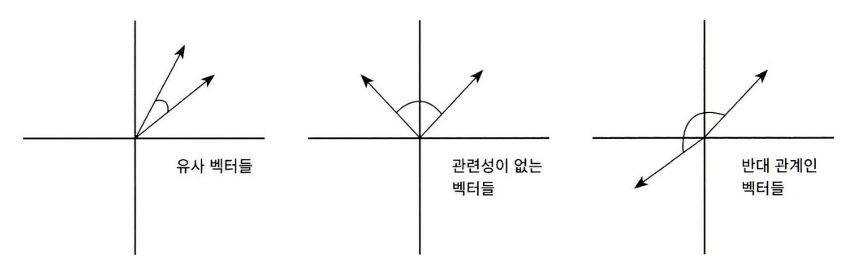
- 유사도 costheta : 두 벡터의 내적을 총 벡터크기의 합으로 나눔 (L2정규화 한것)
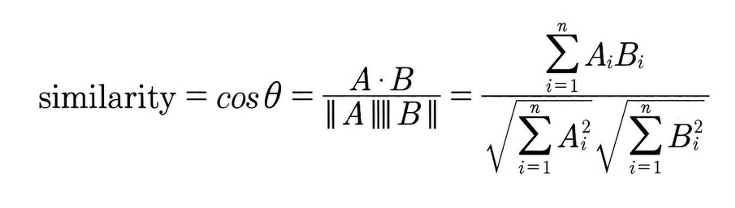

In [11]:
import numpy as np

def cos_similarity(v1,v2):
    dot_product= np.dot(v1,v2)
    l2_norm= (np.sqrt(sum(np.square(v1)))) * np.sqrt(sum(np.square(v2)))
    similarity= dot_product/l2_norm

    return similarity

- doc_list 로 정의된 3개의 간단 문서 유사도 비교하기 위해 TF-IDF로 벡터화된 행렬로 변환하자 -> 왜 3,18이지?

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer

doc_list=['if you take the blue pill, the story ends',
          'if you take the red pill, you stay in Wonderland',
          'if you take the red pill, I show you how deep the rabbit hole goes']

tfidf_vect_simple= TfidfVectorizer()
feature_vect_simple= tfidf_vect_simple.fit_transform(doc_list)
print(feature_vect_simple.shape)

(3, 18)


- 반환된 행렬은 희소 행렬이므로 밀집행렬로 변환한 후 다시 각각을 배열로 변환함
- feature_vect_dense[0]은 doc_list 첫 번째 문서의 피처 벡터화임
- 위에 만든 함수로 두문서의 유사도 측정해보자

In [14]:
# TFidfVectorizer로 transform()한 결과는 희소 행렬이므로 밀집행렬로 변환
feature_vect_dense= feature_vect_simple.todense()

# 첫번째 문장과 두번째 문장의 피처 벡터 추출
vect1= np.array(feature_vect_dense[0]).reshape(-1,)
vect2= np.array(feature_vect_dense[1]).reshape(-1,)

# 첫번째 문장과 두번째 문장의 피처 벡터로 두 개 문장의 코사인 유사도 추출
similarity_simple= cos_similarity(vect1, vect2)
print('문장 1, 문장 2 Cosine 유사도: {0:.3f}'.format(similarity_simple))

문장 1, 문장 2 Cosine 유사도: 0.402


In [18]:
vectl = np.array(feature_vect_dense[0]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect1, vect3 )
print('문장 1, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))
vect2 = np.array(feature_vect_dense[ 1 ]).reshape(-1, )
vect3 = np.array(feature_vect_dense[2]).reshape(-1, )
similarity_simple = cos_similarity(vect2, vect3 )
print('문장 2, 문장 3 Cosine 유사도: {0:.3f}'.format(similarity_simple))


문장 1, 문장 3 Cosine 유사도: 0.404
문장 2, 문장 3 Cosine 유사도: 0.456


- 사이킷런의 코사인 유사도 측정 : sklearn.metrics.pairwise.cosine_similarity API 제공
- cosine_similarity() 함수가 받는 파라미터 1. 비교 기준이 되는 문서의 피처 행렬 2. 비교되는 문서의 피처 행렬
  - 희소, 밀집 행렬 및 배열 모두 가능

In [19]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_simple_pair= cosine_similarity(feature_vect_simple[0], feature_vect_simple)
print(similarity_simple_pair)

[[1.         0.40207758 0.40425045]]


In [22]:
# 자신과의 비교 제외
from sklearn.metrics.pairwise import cosine_similarity
similarity_simple_pair = cosine_similarity(feature_vect_simple[0], feature_vect_simple[1:])
print(similarity_simple_pair)

[[0.40207758 0.40425045]]


- pair 로 코사인 유사도 값 제공 -> ndarray 형태

In [23]:
similarity_simple_pair= cosine_similarity(feature_vect_simple, feature_vect_simple)
print(similarity_simple_pair)
print('shape:', similarity_simple_pair.shape)

[[1.         0.40207758 0.40425045]
 [0.40207758 1.         0.45647296]
 [0.40425045 0.45647296 1.        ]]
shape: (3, 3)


**Opinion Review 데이터 세트를 이용한 문서 유사도 측정**


In [30]:
import nltk

from nltk.tokenize import word_tokenize

from nltk.stem import WordNetLemmatizer

from google.colab import drive

drive.mount('/content/drive')

# 필수 NLTK 데이터 다운로드

nltk.download('punkt')

nltk.download('punkt_tab')

nltk.download('wordnet')


def LemNormalize(text):

    lemmatizer = WordNetLemmatizer()

    return [lemmatizer.lemmatize(token) for token in word_tokenize(text)]


Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [32]:
import pandas as pd
import glob, os
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

path = r'/content/drive/MyDrive/opinosis+opinion+frasl+review/OpinosisDataset1.0/topics'
all_files = glob.glob(os.path.join(path, "*.data"))
filename_list = []
opinion_text = []
for file_ in all_files:

    df = pd.read_table(file_, index_col=None, header=0, encoding='latin1')
    filename_ = file_.split('\\')[-1]
    filename = filename_.split('.')[0]
    filename_list.append(filename)
    opinion_text.append(df.to_string())

document_df = pd.DataFrame({'filename':filename_list, 'opinion_text':opinion_text})
tfidf_vect = TfidfVectorizer(tokenizer=LemNormalize, stop_words='english',
                             ngram_range=(1, 2), min_df=0.05, max_df=0.85 )
feature_vect = tfidf_vect.fit_transform(document_df['opinion_text'])

km_cluster = KMeans(n_clusters=3, max_iter=10000, random_state=0)
km_cluster.fit(feature_vect)
cluster_label = km_cluster.labels_
cluster_centers = km_cluster.cluster_centers_
document_df['cluster_label'] = cluster_label

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ha', 'u', 'wa'] not in stop_words.
  warnings.warn(


In [33]:
from sklearn.metrics.pairwise import cosine_similarity

# clusterjab인=2인 데이터는 호텔로 군집화된 데이터임. DataFrame에서 해당 인덱스를 추출
hotel_indexes = document_df[document_df['cluster_label']==2] .index
print('호텔로 클러스터링 된 문서들의 DataFrame Index： ', hotel_indexes)

# 호텔로 군집화된 데이터 중 첫 번째 문서를 추출해 파일명 표시.
comparison_docname = document_df.iloc[hotel_indexes[0]]['filename']
print('##### 비교 기준 문서명', comparison_docname, ' 와 타 문서 유사도######')

''' document_df에서 추출한 Index 객체를 feature_vect로 입력해 호텔 군집화된 feature_vect 추출
이를 이용해 호텔로 군집화된 문서 중 첫 번째 문서와 다른 문서 간의 코사인 유사도 측정.'''

similarity_pair = cosine_similarity(feature_vect[hotel_indexes[0]], feature_vect[hotel_indexes])
print(similarity_pair)


호텔로 클러스터링 된 문서들의 DataFrame Index：  Index([3, 6, 7, 19, 20, 21, 32, 34, 37, 44], dtype='int64')
##### 비교 기준 문서명 /content/drive/MyDrive/opinosis+opinion+frasl+review/OpinosisDataset1  와 타 문서 유사도######
[[1.         0.06577094 0.07550664 0.08253772 0.03960923 0.04049025
  0.07464435 0.10889616 0.06797805 0.04054824]]


가장 유사도가 큰 파일명 및 유사도:
 filename      /content/drive/MyDrive/opinosis+opinion+frasl+...
similarity                                             0.108896
Name: 34, dtype: object


Text(0.5, 1.0, '/content/drive/MyDrive/opinosis+opinion+frasl+review/OpinosisDataset1')

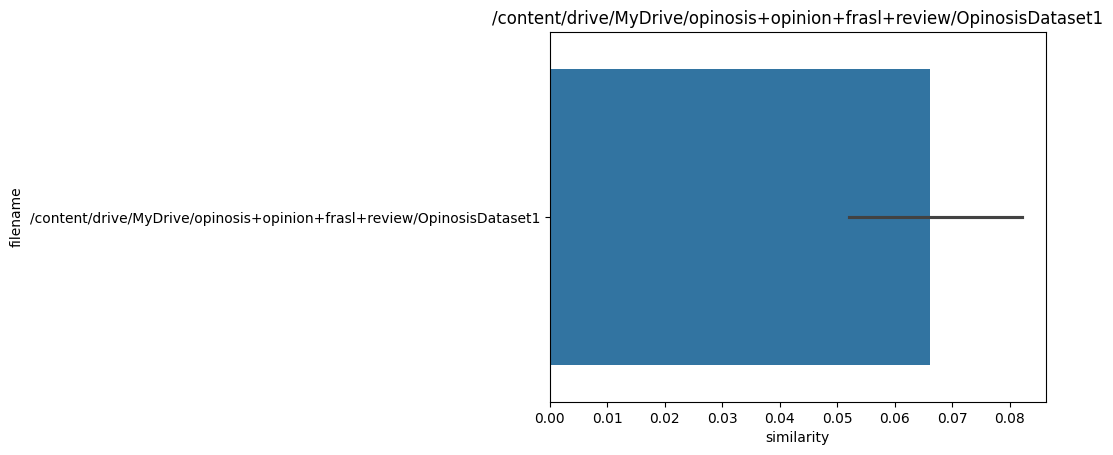

In [38]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# 1. 첫 번째 문서와 타 문서간 유사도가 큰 순으로 정렬한 인덱스 추출 (자기 자신 제외)
sorted_index = similarity_pair.argsort()[:, ::-1]
sorted_index = sorted_index[:, 1:]

# 2. 유사도가 큰 순으로 hotel_indexes를 추출하여 재정렬
hotel_sorted_indexes = hotel_indexes[sorted_index.reshape(-1)]

# 3. 유사도가 큰 순으로 유사도 값을 재정렬하되 자기 자신은 제외
hotel_1_sim_value = np.sort(similarity_pair.reshape(-1))[::-1]
hotel_1_sim_value = hotel_1_sim_value[1:]

# 4. 파일명과 유사도값을 데이터프레임으로 만들고 시각화
hotel_1_sim_df = pd.DataFrame()
hotel_1_sim_df['filename'] = document_df.iloc[hotel_sorted_indexes]['filename']
hotel_1_sim_df['similarity'] = hotel_1_sim_value

print('가장 유사도가 큰 파일명 및 유사도:\n', hotel_1_sim_df.iloc[0, :])

sns.barplot(x='similarity', y='filename', data=hotel_1_sim_df)
plt.title(comparison_docname)

In [39]:
pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 495.9/495.9 kB 14.6 MB/s eta 0:00:00


In [42]:
import pandas as pd
train_df = pd.read_csv('ratings_train.txt', sep='\t', encoding='utf-8')
train_df.head(3)

,id,document,label
0,9976970,아 더빙.. 진짜 짜증나네요 목소리,0
1,3819312,흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나,1
2,10265843,너무재밓었다그래서보는것을추천한다,0


In [43]:
train_df['label'].value_counts( )

,count
label,
0,75173
1,74827


In [46]:
import re
train_df = train_df.fillna(' ')
# 정규 표현식을 이용해 숫자를 공백으로 변경(정규 표현식으로 \d는 숫자를 의미함.)
train_df['document'] = train_df['document'].apply( lambda x : re.sub(r"\d+", " ", x) )
# 테스트 데이터 세트를 로딩하고 동일하게 Null 및 숫자를 공백으로 변환
test_df = pd.read_csv('ratings_test.txt', sep='\t', encoding='utf-8')
test_df = test_df.fillna(' ')
test_df['document'] = test_df['document'].apply( lambda x: re.sub(r"\d+", " ", x) )

# id 칼럼 삭제 수행
train_df.drop('id', axis=1, inplace=True)
test_df.drop('id', axis=1, inplace=True)

In [48]:
from konlpy.tag import Twitter
twitter = Twitter()
def tw_tokenizer(text):
    # 입력 인자로 들어온 텍스트를 형태소 단어로 토큰화해 리스트 형태로 반환
    tokens_ko = twitter.morphs(text)
    return tokens_ko

/usr/local/lib/python3.12/dist-packages/konlpy/tag/_okt.py:17: UserWarning: "Twitter" has changed to "Okt" since KoNLPy v0.4.5.
  warn('"Twitter" has changed to "Okt" since KoNLPy v0.4.5.')


In [51]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
# Twitter 객체의 morphs( ) 객체를 이용한 tokenizer를 사용. ngram_range는 (1, 2)
tfidf_vect = TfidfVectorizer(tokenizer=tw_tokenizer, ngram_range=(1, 2), min_df=3, max_df=0.9)
tfidf_vect.fit(train_df['document'])
tfidf_matrix_train = tfidf_vect.transform(train_df['document'])

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

# 1. 로지스틱 회귀 모델 초기화
lg_clf = LogisticRegression(random_state=0, solver='liblinear')

# 2. 파라미터 C 최적화를 위한 설정
params = { 'C': [1, 3.5, 4.5, 5.5, 10] }

# 3. GridSearchCV 설정 및 학습
grid_cv = GridSearchCV(lg_clf, param_grid=params, cv=3, scoring='accuracy', verbose=1)
grid_cv.fit(tfidf_matrix_train, train_df['label'])

# 4. 결과 출력
print(grid_cv.best_params_, round(grid_cv.best_score_, 4))

In [ ]:
from sklearn.metrics import accuracy_score

# 1. 학습할 때 사용한 tfidf_vect를 그대로 사용하여 테스트 데이터를 변환 (fit_transform이 아님에 주의!)
tfidf_matrix_test = tfidf_vect.transform(test_df['document'])

# 2. GridSearchCV에서 찾은 최적의 모델(best_estimator_)을 가져옴
best_estimator = grid_cv.best_estimator_

# 3. 테스트 데이터로 예측 수행
preds = best_estimator.predict(tfidf_matrix_test)

# 4. 정확도 출력
print('Logistic Regression 정확도:', accuracy_score(test_df['label'], preds))